In [34]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

#Global normailization

hysea=True

if hysea is False:
    mags=np.genfromtxt("/Users/seansantellanes/Downloads/dtopos_df_3.txt",skip_header=1,delimiter=",",usecols=1)
    centroid=np.genfromtxt("/Users/seansantellanes/Downloads/dtopos_df_3.txt",skip_header=1,delimiter=",",usecols=(2,3,4))
    geoclaw_compare=np.load("/Users/seansantellanes/Downloads/geoclaw_toy_database.npz")
    data=geoclaw_compare["eta"][:-1]
    data.shape
elif hysea is True:
    mags=np.genfromtxt("/Users/seansantellanes/Downloads/mw_list_2.txt",skip_header=0,delimiter=" ")
    centroid=np.genfromtxt("/Users/seansantellanes/Downloads/location_df_thousand.txt",skip_header=0,delimiter=" ")
    mags=mags[np.argsort(mags[:,0])]
    centroid=centroid[np.argsort(centroid[:,0])]
    geoclaw_compare=np.load("/Users/seansantellanes/Downloads/combined_eta_thousand.npz")
    data=geoclaw_compare["eta"][:]
    data=data.reshape(980,480,356)
    data=np.transpose(data,(0,2,1))
    data.shape

In [35]:
print(np.max(mags[:,1]))

8.676546


In [36]:
mags=np.genfromtxt("/Users/seansantellanes/Downloads/dtopos_df_3.txt",skip_header=1,delimiter=",",usecols=1)
centroid=np.genfromtxt("/Users/seansantellanes/Downloads/dtopos_df_3.txt",skip_header=1,delimiter=",",usecols=(2,3,4))
geoclaw_compare=np.load("/Users/seansantellanes/Downloads/geoclaw_toy_database.npz")
data_geo=geoclaw_compare["eta"][:-1]
data_geo.shape

(1000, 356, 480)

In [37]:
print(np.max(mags))

8.5443


Text(0, 0.5, 'Amplitude')

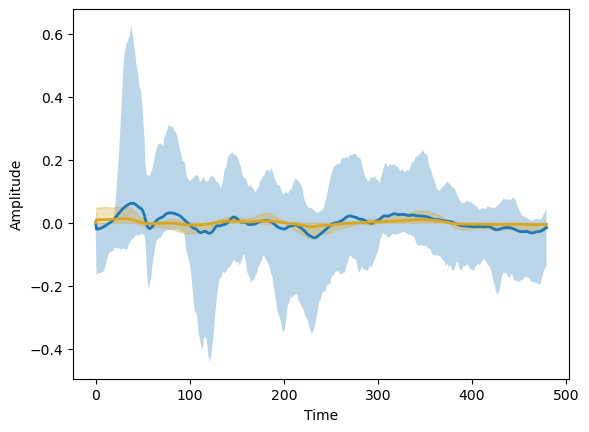

In [11]:
import matplotlib.pyplot as plt
station = 355

data_copy = data[:, station, :]  # (1000, 480)
data_geo_copy = data_geo[:, station, :]
mean = data_copy.mean(axis=0)
p05 = np.percentile(data_copy, 5, axis=0)
p95 = np.percentile(data_copy, 95, axis=0)
mean_geo = data_geo_copy.mean(axis=0)
p05_geo = np.percentile(data_geo_copy, 5, axis=0)
p95_geo = np.percentile(data_geo_copy, 95, axis=0)

plt.fill_between(range(480), p05, p95, alpha=0.3)
plt.plot(mean, lw=2)
plt.fill_between(range(480), p05_geo, p95_geo, alpha=0.3,color='goldenrod')
plt.plot(mean_geo, lw=2,color='goldenrod')
plt.xlabel("Time")
plt.ylabel("Amplitude")

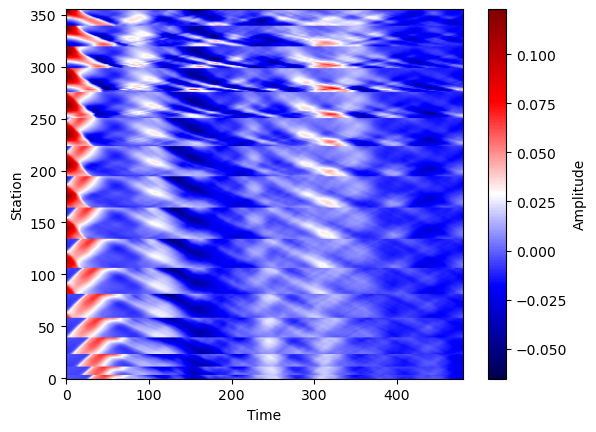

In [12]:
mean_wavefield = data.mean(axis=0)  # (356, 480)

plt.imshow(
    mean_wavefield,
    aspect="auto",
    origin="lower",
    cmap="seismic"
)

plt.xlabel("Time")
plt.ylabel("Station")
plt.colorbar(label="Amplitude")

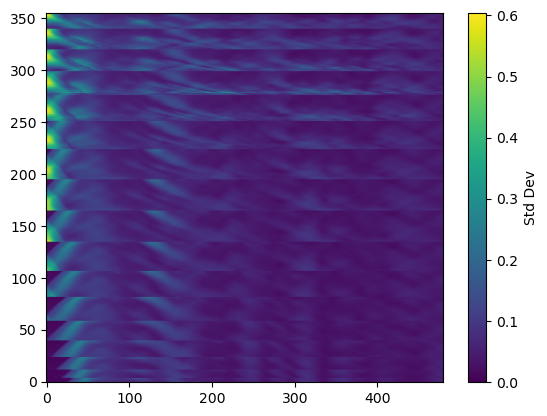

In [13]:
std_wavefield = data.std(axis=0)

plt.imshow(
    std_wavefield,
    aspect="auto",
    origin="lower"
)
plt.colorbar(label="Std Dev")

Text(0, 0.5, 'Realization')

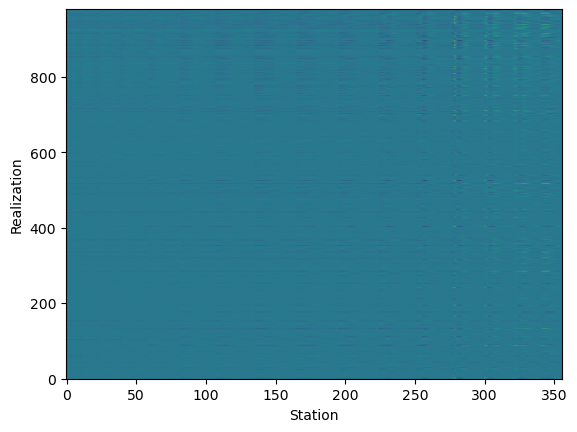

In [14]:
t = 200

plt.imshow(
    data[:, :, t],
    aspect="auto",
    origin="lower"
)

plt.xlabel("Station")
plt.ylabel("Realization")

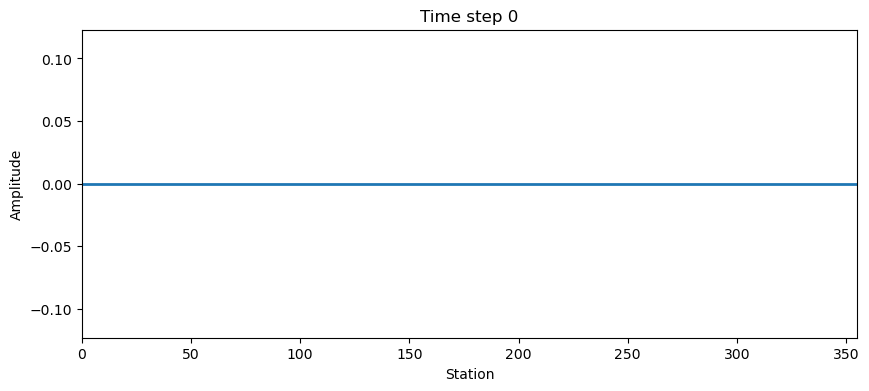

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# cube.shape = (1000, 356, 480)

# Ensemble mean wavefield
wavefield = data.mean(axis=0)  # (356, 480)

fig, ax = plt.subplots(figsize=(10, 4))

line, = ax.plot(wavefield[:, 0], lw=2)

ax.set_xlim(0, wavefield.shape[0] - 1)

# Fix y-limits so the scale doesn't jump
ymax = np.abs(wavefield).max()
ax.set_ylim(-ymax, ymax)

ax.set_xlabel("Station")
ax.set_ylabel("Amplitude")

title = ax.set_title("Time step 0")

def update(t):
    line.set_ydata(wavefield[:, t])
    title.set_text(f"Time step {t}")
    return line, title

anim = FuncAnimation(
    fig,
    update,
    frames=wavefield.shape[1],  # 480 time steps
    interval=30,                # ms/frame
    blit=True
)

plt.show()

In [16]:
anim.save(
    "wavefield.mp4",
    writer="ffmpeg",
    fps=30,
    dpi=150
)